# ANN (Artificial neural network) for Regression

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
# Load DataSets
df=pd.read_csv("2_powerplant_data.csv")
X=df.drop("PE",axis=1)
y=df["PE"]

In [3]:
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2)
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

# Converting All data (X_train) in tensor

In [4]:
# we used tensor converting all data because ANN expect wo dl/dx ko easy handle krta hai 
import torch 
import torch.nn as nn

In [5]:
X_train_tensor=torch.tensor(X_train_scaled,dtype=torch.float32)
X_test_tensor=torch.tensor(X_test_scaled,dtype=torch.float32)
y_train_tensor=torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)
y_test_tensor=torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)
 # we convert in tensor because pytorch automatically handles the grdaient which is dy/dx proper if it get tensor values

# ANN Architecture

In [6]:
from torch.utils.data import DataLoader,TensorDataset


In [7]:
# DatatSet help to access data from system memory because DataLoader can't access the data directly and 
# dataset also have the feature of gieving data in one or batch size
train_dataset=TensorDataset(X_train_tensor,y_train_tensor)
test_dataset=TensorDataset(X_test_tensor,y_test_tensor)
train_DataLoader=DataLoader(train_dataset,batch_size=32,shuffle=True)
test_DataLoader=DataLoader(test_dataset,batch_size=32)

# Deep Learning

In [8]:
# Build ANN MODEL
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(X_train.shape[1], 6),  # 1st Hidden Layer
            nn.ReLU(),
            nn.Linear(6, 6),           # 2nd Hidden Layer
            nn.ReLU(),
            nn.Linear(6, 1)            # Output Layer
        )

    def forward(self, X):
        return self.model(X)

In [9]:
import torch.optim as optim ##Optimizer
model=ANN()
# Loss, Optmizer
crietrion=nn.MSELoss()
optimizer=optim.Adam(model.parameters())

# Train the ANN

In [10]:
train_losses=[]
val_losses=[]
epochs=100
best_val_loss=float("inf")
for epoch in range(epochs):
    model.train()
    running_loss=0.0  # yha store krenge total training loss for 1 epoch
    for xb,yb in train_DataLoader:
        # xb= feature of 1 batch
        # yb=lavels of 1 batch
        optimizer.zero_grad()
        
        outputs=model(xb) # forward prop.... predicted outputs for this batch
        loss=crietrion(outputs,yb) # compute loss
        loss.backward() # back prop... compute gradients
        optimizer.step() #params update

        running_loss += loss.item()
        
    epoch_train_loss=running_loss/len(train_DataLoader)
    train_losses.append(epoch_train_loss)

    # Validation
    model.eval()
    running_val_loss=0.0
    with torch.no_grad(): # no gradient compute
        for xb,yb in test_DataLoader:
            outputs=model(xb)
            loss=crietrion(outputs,yb)
            running_val_loss +=loss
    epoch_val_loss=running_val_loss/len(test_DataLoader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs}==>train loss= {epoch_train_loss}& val_loss={epoch_val_loss}")
    if best_val_loss>epoch_val_loss:
        best_val_loss=epoch_val_loss
        torch.save(model.state_dict(),"best_model.pt") ## yha .pt ya .pth
        

epoch 1/100==>train loss= 205876.86770833333& val_loss=204316.53125
epoch 2/100==>train loss= 200033.2962890625& val_loss=192942.890625
epoch 3/100==>train loss= 179452.44446614583& val_loss=162863.171875
epoch 4/100==>train loss= 141056.77047526042& val_loss=118860.5703125
epoch 5/100==>train loss= 96071.92722981771& val_loss=75917.7109375
epoch 6/100==>train loss= 59103.32290039062& val_loss=46054.1171875
epoch 7/100==>train loss= 36642.80194498698& val_loss=29833.60546875
epoch 8/100==>train loss= 24881.450756835937& val_loss=21255.787109375
epoch 9/100==>train loss= 18570.633736165364& val_loss=16439.587890625
epoch 10/100==>train loss= 14798.083268229168& val_loss=13223.068359375
epoch 11/100==>train loss= 11943.899112955729& val_loss=10507.1611328125
epoch 12/100==>train loss= 9405.717985026042& val_loss=8057.595703125
epoch 13/100==>train loss= 7095.180294799805& val_loss=5906.70263671875
epoch 14/100==>train loss= 5078.181587727865& val_loss=4092.6240234375
epoch 15/100==>train

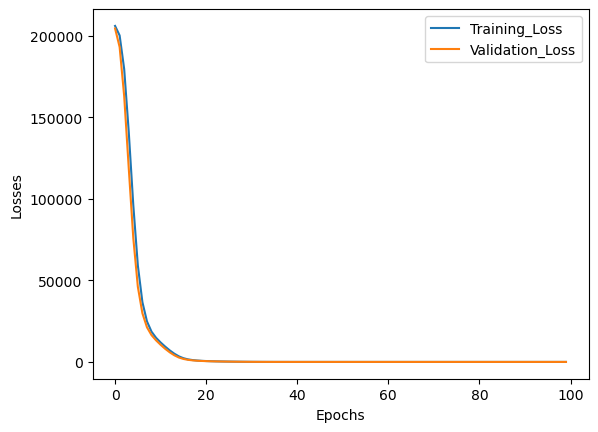

In [11]:
import matplotlib.pyplot as plt
loss_df=pd.DataFrame({
    "Trainign_Loss":train_losses,
    "Validation_Loss":val_losses
})
plt.plot(loss_df["Trainign_Loss"],label="Training_Loss")
plt.plot(loss_df["Validation_Loss"],label="Validation_Loss")
plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.legend()

# Loading the Saved Model

In [13]:
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>